# Human in the Loop

In [19]:
import os
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

llm = ChatGroq(model="openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001FFF4CB6F60>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001FFF4CB1010>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [25]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human"""
    human_response = interrupt({"query" : query})
    return human_response["data"]

tool = TavilySearch(max_results=1)
tools = [tool, human_assistance]

llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Since we want to interupt the tool execution, we disable parallel tool calling to avoid repeating any tool invocations when we resume

    return {"messages" : [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools = tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [26]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

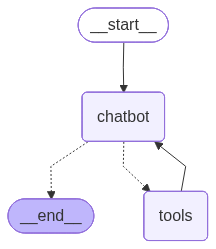

In [27]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
user_input = "I need some expert guidance for building AI agent. Could you request assistance from me?"
config = {"configurable" : {"thread_id" : "1"}}

events = graph.stream(
    {"messages" : user_input},
    config,
    stream_mode = "values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building AI agent. Could you request assistance from me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_b4ec17c8-892d-4060-9272-c6f6155fe6d0)
 Call ID: fc_b4ec17c8-892d-4060-9272-c6f6155fe6d0
  Args:
    query: Could you provide more details about your AI agent project? I can offer expert guidance.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_b4ec17c8-892d-4060-9272-c6f6155fe6d0)
 Call ID: fc_b4ec17c8-892d-4060-9272-c6f6155fe6d0
  Args:
    query: Could you provide more details about your AI agent project? I can offer expert guidance.


In [29]:
user_input = "Yeah sure. It will be a RAG project"
config = {"configurable" : {"thread_id" : "1"}}

events = graph.stream(
    {"messages" : user_input},
    config,
    stream_mode = "values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

Yeah sure. It will be a RAG project
================================== Ai Message ==================================

Below is a “starter‑kit” for building a Retrieval‑Augmented Generation (RAG) AI agent, followed by a set of clarifying questions that will help us drill into the details of your particular project.  
Feel free to skip the questions that don’t apply or to add any extra context you think is relevant.

---

## 1. High‑level RAG Architecture

```
┌───────────────────────┐
│  1. Data Source       │
│     • PDFs, HTML,     │
│       internal docs,  │
│       web pages, etc. │
└────────────┬──────────┘
             │
             ▼
┌───────────────────────┐
│ 2. Ingestion Pipeline │
│     • Scraping/ETL    │
│     • Chunking (512‑1024 B) │
│     • Pre‑processing  │
│     • Metadata tagging│
└────────────┬──────────┘
             │
             ▼
┌───────────────────────┐
│ 3. Embedding Engine   │

--- Node: Generating Content ---
Graph State Update: {'generator': {'content': 'This is a great tutorial, damn it!', 'status': 'pending'}}
------------------------------
--- Node: Moderating Content ---
--- Routing Based on Status: flagged ---
Graph State Update: {'moderator': {'status': 'flagged'}}
------------------------------
--- Node: Rewriting Flagged Content ---
Graph State Update: {'rewriter': {'content': 'This is a great tutorial, look at it!', 'status': 'pending'}}
------------------------------
--- Node: Moderating Content ---
--- Routing Based on Status: clean ---
Graph State Update: {'moderator': {'status': 'clean'}}
------------------------------
--- Node: Publishing Clean Content ---
Graph State Update: {'publisher': {'content': 'This is a great tutorial, look at it!'}}
------------------------------


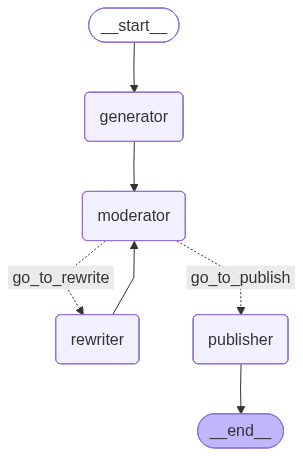

In [12]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

# 1. Define the Graph State
class WorkflowState(TypedDict):
    content: str
    status: Literal["clean", "flagged", "pending"]

# 2. Define the Nodes
def generate_content(state: WorkflowState):
    print("--- Node: Generating Content ---")
    # Simulation: Try changing this text to something clean to see the other path
    return {"content": "This is a great tutorial, damn it!", "status": "pending"}

def moderate_content(state: WorkflowState):
    print("--- Node: Moderating Content ---")
    flagged_words = ["damn", "blast", "heck"]
    
    # Check if any flagged word exists in the text
    if any(word in state["content"].lower() for word in flagged_words):
        return {"status": "flagged"}
    return {"status": "clean"}

def rewrite_content(state: WorkflowState):
    print("--- Node: Rewriting Flagged Content ---")
    # Clean the text and update state
    return {"content": "This is a great tutorial, look at it!", "status": "pending"}

def publish_content(state: WorkflowState):
    print("--- Node: Publishing Clean Content ---")
    return {"content": state["content"]}

# 3. Define the Routing Function (The Condition)
def router_condition(state: WorkflowState) -> str:
    print(f"--- Routing Based on Status: {state['status']} ---")
    
    if state["status"] == "clean":
        return "go_to_publish"
    else:
        return "go_to_rewrite"

# 4. Construct the Graph
builder = StateGraph(WorkflowState)

# Add nodes
builder.add_node("generator", generate_content)
builder.add_node("moderator", moderate_content)
builder.add_node("rewriter", rewrite_content)
builder.add_node("publisher", publish_content)

# Add static (unconditional) edges
builder.add_edge(START, "generator")
builder.add_edge("generator", "moderator")
builder.add_edge("rewriter", "moderator") # Loop back to check updated content
builder.add_edge("publisher", END)

# Add the CONDITIONAL EDGE after the moderator node
builder.add_conditional_edges(
    "moderator",            # 1. Start from this node
    router_condition,       # 2. Call this function to decide where to go
    {                       # 3. Map function outputs to real node names
        "go_to_publish": "publisher",
        "go_to_rewrite": "rewriter"
    }
)

# Compile the graph
graph = builder.compile()

# 5. Execute the Graph
initial_input = {"content": "", "status": "pending"}
for event in graph.stream(initial_input):
    print("Graph State Update:", event)
    print("-" * 30)


from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))
